In [1]:
# 노트북 파일을 로컬에서 만든 후 clone한 폴더로 이동

# !mv /content/Simulation.ipynb /content/drive/MyDrive/study_DataTechniques/04.\ Numerical\ Simulation/simulation.ipynb

## 수치 시뮬레이션

: 수학적 모델을 사용하여 물리적 현상이나 시스템을 컴퓨터로 모의 실험하는 것을 의미합니다.                
   주로 수치해석학(numerical analysis) 기법을 활용하여 근사해를 구하는 과정을 포함합니다.           
                   
: 미래 예측을 위한 선택지를 늘려가는 방법           

고객의 소리)               
물류 비용 개선에서 다양한 것을 알 수 있었습니다. 이번에는 우리 회사 **"제품의 판매를 예측할 수 있는지"**를 검토해줬으면 합니다. 우리 제품은 대대적인 홍보를 하지는 않지만 거의 **SNS를 통해 입소문**을 타고 퍼지고 있습니다. **재구매 고객은 우리와 SNS로 연결돼** 있어 파악이 가능합니다. 이것을 이용해 앞으로의 매출을 예측할 수 있을까요?

데이터)                   
              
links.csv : 재구매 고객 20명 간 SNS 연결 상태(0 : 연결X, 1 : 연결O)                  
links_members.csv : 모든 재구매 고객 540명의 SNS 연결 상태                 
info_members.csv : 모든 재구매 고객 540명의 2년간 월별 이용 현황(0 : 이용 실적 X, 1 : 이용 실적 O)

## 인간관계 네트워크 가시화

In [2]:
from google.colab import drive
drive.mount('/content/drive') # content/임시공간

Mounted at /content/drive


In [3]:
# !ls "/content/drive/MyDrive/Colab Notebooks/4장_data"

In [4]:
import pandas as pd

df_links = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/4장_data/links.csv", index_col = 0)
df_links.head()

# 1 : 연결되어 있다
# 0 : 연결되어 있지 않다

,Node0,Node1,Node2,Node3,Node4,Node5,Node6,Node7,Node8,Node9,Node10,Node11,Node12,Node13,Node14,Node15,Node16,Node17,Node18,Node19
Node0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Node1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
Node2,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Node3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Node4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## SNS 연결 가시화

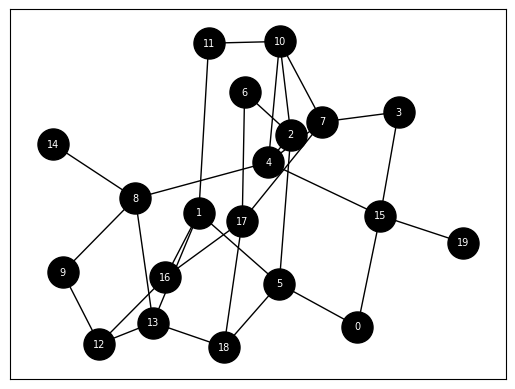

In [5]:
# network를 이용한 가시화
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

node_list = []
for i in range(len(df_links.columns)) :
  node_nm =df_links.columns[i].split("Node")[1]
  G.add_node(node_nm)
  node_list.append(node_nm)

# weights_list = []
for i in range(len(df_links.index)) :
  for j in range(len(df_links.columns)) :
    if df_links.iloc[i, j] == 1 :
      G.add_edge(node_list[i], node_list[j])
      # weights_list.append(df_links.iloc[i, j])

# pos = {}

nx.draw_networkx(G, with_labels= True, font_color = 'w', node_color= 'k', node_size= 500, font_size= 7)
plt.show()

# 네트워크 가시화에서 이전에 사용한 draw가 아닌 draw_networkx를 사용합니다.
# 이 함수는 *다른 것과 연결이 많은 노드를 중심에 오게* 자동으로 위치를 결정해서 가시화합니다.
# 재현성이 없기 때문에 실행할 때마다 다른 그래프가 표시되지만
# 모든 노드로부터 연결이 있는 노드에 대해 정확하게 엣지가 연결되어 있으면 가시화는 성공이라고 할 수 있습니다.

In [6]:
# dir(nx.Graph) # add_edge, add_node,
# dir(nx) # draw_networkx

In [7]:
# # 교재)
# import networkx as nx
# import matplotlib.pyplot as plt

# G = nx.Graph()

# num = len(df_links.index)

# for i in range(num) :
#   node_no = df_links.columns[i].strip("Node")
#   G.add_node(str(node_no))

# for i in range(num) :
#   for j in range(num) :
#     node_nm = 'Node' + str(j)
#     if df_links[node_nm].iloc[i] == 1 :
#       G.add_edge(str(i), str(j))

# # 그리기
# nx.draw_networkx(G,node_color= 'k', edge_color= 'k', font_color= 'w')
# plt.show()

## 입소문에 의한 정보 전파 모습 가시화

In [8]:
# df_links['Node19'] # 0, 5, 15. 18, 19 # i = 0일때 돌 수 있는 i들
# t=0일 때(1번만 순회) list_active = [1,1,1,1,1,1,0,0,0,0,0,0,0,1,0,1,0,1,1,1] - 100% 전파라면

In [9]:
# 불러 온 네트워크 구조를 이용해 입소문이 전파되는 모습을 시뮬레이션
# 가정 : 10개의 연결 중 하나의 확률(10%의 확률)로 소문이 전파된다.

import numpy as np

def determine_link(percent):
    rand_val = np.random.rand()
    if rand_val <= percent :
        return 1
    else :
        return 0

def simulate_percolation(num, list_active, percent_perlocation) :
    for i in range(num) :
        if list_active[i] == 1 :
            for j in range(num) :
                node_name = 'Node' + str(j)
                if df_links[node_name].iloc[i] == 1 :
                    if determine_link(percent_percolation) == 1 :
                        list_active[j] = 1
    return list_active

# determine_link는 입소문의 전파 여부를 확률적으로 결정하는 함수로
# 인수로 입소문을 낼 확률을 전달합니다.

# simulate_percolation(침투/확산)은 입소문을 시뮬레이션하는 함수로
# num : 사람 수
# list_active : 각자의 노드(사람)에 입소문이 전달됐는지를 1 또는 0으로 표현한 배열
# percent_percolation : 입소문을 일으킬 확률

# **
# Node0에 해당하는 사람이 Node0~19와 연결되어 있을 때(df_links[].iloc[i] == 1)
# 전파 확률에 따라 list_active = 0 / 1


In [10]:
percent_percolation = 0.1
T_NUM = 36
NUM = len(df_links.index) # 20
list_active = np.zeros(NUM)
list_active[0] = 1

list_timeSeries = []
for t in range(T_NUM) :
  list_active = simulate_percolation(NUM, list_active, percent_percolation)
  list_timeSeries.append(list_active.copy())

# percent_percolation = 0.1 : 입소문을 일으킬 확률 10%
# 이를 36스텝 반복
# > 한 달에 입소문을 일으킬 확률은 10%, 이것을 36개월 반복

len(list_timeSeries) # 36
# list_timeSeries # 길이 20 리스트가 36개

# t = 0
# timeSeries = [[1, 0 x 19]] - range(0) > 실행 x
# t = 1
# timeSeries = [[1, 0 x 19], [1, ]]

36

## 입소문 전파 가시화

In [11]:
def active_node_coloring(list_active) :
  list_color = []
  for i in range(len(list_timeSeries[t])) : # 모든 개월 수 그리지 않고 특정 개월 수 주어질 예정
  # 특정 개월 수의 len은 20
    if list_timeSeries[t][i] == 1 :
      list_color.append('r')
    else :
      list_color.append('k')
  return list_color

# 연결된 노드는 'r' 색상
# 연결되지 않는 노드는 'k' 색상


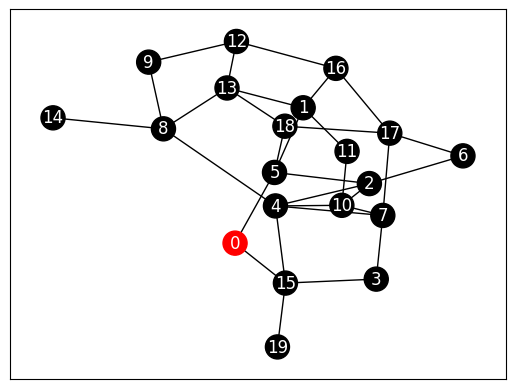

[0, 1, 2, 3, 4, 5, 13, 15, 17, 18, 19]

In [12]:
t = 0

nx.draw_networkx(G, font_color= 'w', node_color = active_node_coloring(list_timeSeries[t]))
plt.show()

# t = 0 (1개월 차)
# 전파 정도 = 100%
# list_timeSeries = [[1,1,1,1,1,1,0,0,0,0,0,0,0,1,0,1,0,1,1,1], ,,,]
# > 0,1,2,3,4,5,13,15,17,18,19
temp_list =  [19,15, 0, 3, 4, 5, 2, 18, 17, 1, 13]
temp_list.sort()
temp_list
# 일치


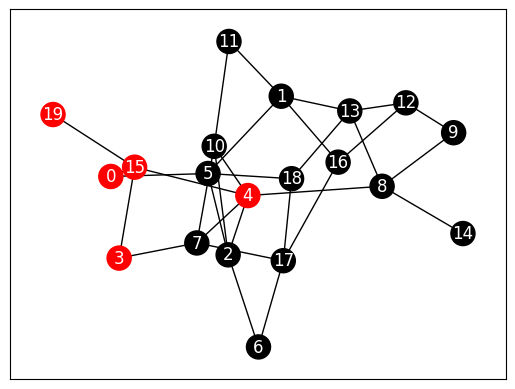

In [13]:
t = 11 # 1년
nx.draw_networkx(G, font_color = 'w', node_color = active_node_coloring(list_timeSeries[t]))
plt.show()

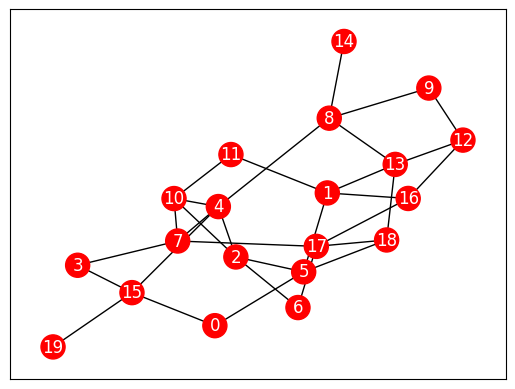

In [14]:
t = 35 # 마지막 개월수
nx.draw_networkx(G, font_color = 'w', node_color= active_node_coloring(list_timeSeries[t]))


# active_node_coloring은 입소문이 전파된(활성화된) 노드는 빨간색으로
# 아직 전파되지 않은(활성화되지 않은) 노드는 검은색으로 색칠하는 함수입니다.
# 이것으로 t=0, t=11, 35(1개월 후, 12개월 후, 36개월 후)를 표시합니다.
# 12개월까지는 완만한 전파였지만 오랜 시간이 경과하면 거의 전원에게 전파되는 모습을 확인할 수 있습니다.


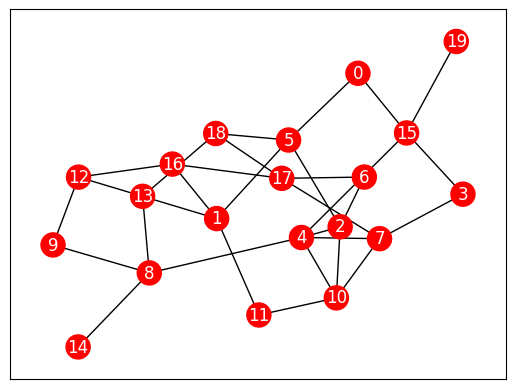

In [15]:
# 실습)
# 입소문 전파 시각화

import numpy as np

def percolation_percentage(percent) :
  rand_num = np.random.rand() # 0~1사이의 값
  if rand_num <= percent :
    return 1
  else :
    return 0

def activate_node(num, list_activated, percent) :
  for i in range(num) :
    if list_activated[i] == 1 :
      for j in range(num) :
        node_nm = 'Node' + str(j)
        if df_links[node_nm].iloc[i] == 1 :
          if percolation_percentage(percent) == 1 :
            list_activated[j] = 1
  return list_activated

num = len(df_links)
time_series = 36
list_activated = np.zeros(num)
list_activated[0] = 1
perco_percent = 0.1

list_timeSeries = []
for t in range(time_series) :
  list_activated = activate_node(num, list_activated, perco_percent)
  list_timeSeries.append(list_activated.copy())

len(list_timeSeries) # 36

list_coloring = []
def activate_node_coloring(list_timeSeries, t) :
  list_activated = list_timeSeries[t]
  for i in range(len(list_activated)) :
    if list_activated[i] == 1 :
      list_coloring.append('r')
    else :
      list_coloring.append('k')
  return list_coloring # ***return

import networkx as nx

# nx.draw_networkx(G, font_color = 'w', node_color = activate_node_coloring(list_timeSeries, 0))
# plt.show()

# 1년 후) 0, 5, 15, 19
# nx.draw_networkx(G, font_color = 'w', node_color = activate_node_coloring(list_timeSeries, 11))
# plt.show()

# 3년 후) 전체
nx.draw_networkx(G, font_color = 'w', node_color = activate_node_coloring(list_timeSeries, 35))
plt.show()


## 입소문 수의 시계열 변화 그래프화

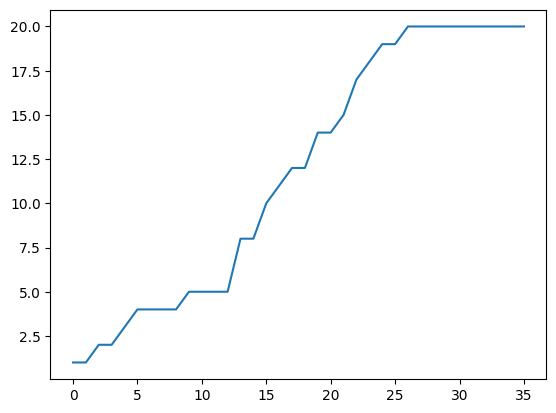

In [16]:
# 1개월~36개월 모두 가시화하여 언제 어떻게 입소문 전파가 이루어졌는지 알 수 있습니다
# 입소문이 난 수를 시계열로 표현하는 것만으로도 입소문이 퍼지는 전체 모양을 대략 파악할 수 있습니다.

list_timeSeries_num = []

for i in range(len(list_timeSeries)) : # 36
  list_timeSeries_num.append(sum(list_timeSeries[i]))

# list_timeSeries_num > 36개월동안 누적된 전파 수

plt.plot(list_timeSeries_num)
plt.show()

# 1개월차 0개에서 36개월차에는 20개 전부 전파된 것을 확인할 수 있음
# 각 시점에서 입소문이 전파한 수를 표시하면 이렇게 단계적으로 입소문이 나는 모습을 확인할 수 있습니다.
# 확률적으로 계산하기 때문에 결과가 조금 다를수 있지만
# 서서히 전파되어 전원에게 전파되는 모습이 확인되면 문제없습니다.


## 회원 수의 시계열 변화 시뮬레이션

##### **입소문을 통해 스포츠 센터의 이용 상황이 어떻게 변화**해가는지를 시뮬레이션해 봅시다.         
2장에서 다룬 스포츠 센터 분석과 시뮬레이션을 함께 하면 미래를 예측할 수 있습니다           
또 **입소문에 의한 스포츠 센터 회원의 소비자 행동 분석 과정**은 **소비자 행동을 분석하는 과제**라면 어디에나 사용할 수 있는 일반적인 방법입니다.

In [20]:
# percent_percolation = 0.1
# percent_disappearance = 0.05

def simulate_population(num, list_activated, percent_percolation, percent_disappearance, df_links) :
  # 확산 : node간 연결을 활용한
  for i in range(num) :
    if list_activated[i] == 1 :
      for j in range(num) :
        if df_links.iloc[i][j] == 1 :
          if determine_link(percent_percolation) == 1 :
            list_activated[j] = 1
  # 소멸 : 모든 노드 중 5%의 확률로 삭제될 가능성 존재
  for i in range(num) :
    if determine_link(percent_disappearance) == 1 :
      list_activated[i] = 0
  return list_activated


In [18]:
percent_percolation = 0.1
percent_disappearance = 0.05
time_series = 100
num = len(df_links)
list_activated = np.zeros(num)
list_activated[0] = 1

list_timeSeries = []
for t in range(time_series) :
  list_activated = simulate_population(num, list_activated, percent_percolation, percent_disappearance, df_links)
  list_timeSeries.append(list_activated.copy())

/tmp/ipython-input-17-2414512599.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if df_links.iloc[i][j] == 1 :


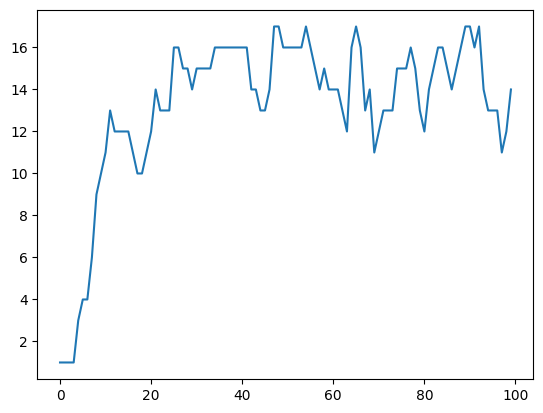

In [19]:
# 시계열 그래프 그리기
list_timeSeries_num = []

for t in range(len(list_timeSeries)) :
  list_timeSeries_num.append(list_timeSeries[t].sum())

# list_timeSeries_num
plt.plot(list_timeSeries_num)
plt.show()


  # 입소문 확산뿐만 아니라 새롭게 '소멸'이라는 조작도 추가합니다
  # 스포츠 센터의 회원은 지금까지 센터를 이용하던 사람이 어느 날 갑자기 이용하지 않는(탈퇴) 경우도 있습니다.
  # 여기서는 그러한 일이 5%의 확률로 일어난다고 가정하고
  # 입소문에 의한 회원 증가와 감소의 모습을 시뮬레이션합니다.
  # 그러면 그림과 같이 증감을 반복하면서 서서히 100%의 이용률을 향해가는 모습을 확인할 있습니다.
  # 전원은 아니지만 커뮤니티의 입소문 힘으로 조금씩 스포츠센터를 이용하는 힘이 강해지는 것으로 보아
  # 현실에 맞는 시뮬레이션 결과라는 것을 알수 있습니다

  # 한편, 소멸의 확률을 조금 늘려보면 이번에는 이용자가 줄어드는 모습을 확인할 수 있습니다.

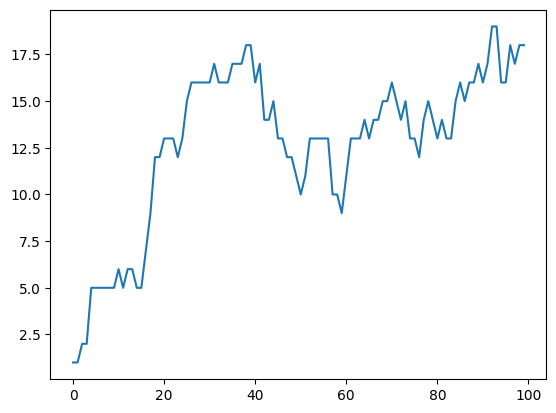

In [22]:
# 실습)
# 스포츠 센터 회원 입소문 시뮬레이션
import numpy as np
import matplotlib.pyplot as plt

def percolation_percentage(percentage) :
  rand_num = np.random.rand()
  if rand_num <= percentage :
    return 1
  else :
    return 0

def simulation_membership_percolation(num, list_activated, df_links, percentage_percolation, percentage_disappearance) :
  for i in range(num) :
    if list_activated[i] == 1 :
      for j in range(num) :
        node_nm = 'Node' + str(j)
        if df_links[node_nm].iloc[i] == 1 :
          if percolation_percentage(percentage_percolation) == 1 :
            list_activated[j] = 1

  for i in range(num) :
    if percolation_percentage(percent_disappearance) == 1 :
      list_activated[i] = 0

  return list_activated

t_period = 100
num = len(df_links)
percentage_percolation = 0.1
percentage_disappearance = 0.05
list_activated = np.zeros(num)
list_activated[0] = 1

list_timeSeries = []
for t in range(t_period) :
  list_activated = simulation_membership_percolation(num, list_activated, df_links,percent_percolation, percentage_disappearance)
  list_timeSeries.append(list_activated.copy())

list_timeSeries_num = []
for i in range(len(list_timeSeries)) :
  list_timeSeries_num.append(list_timeSeries[i].sum())

plt.plot(list_timeSeries_num)
plt.show()


# 결국 20명 전원 고객으로 수렴함


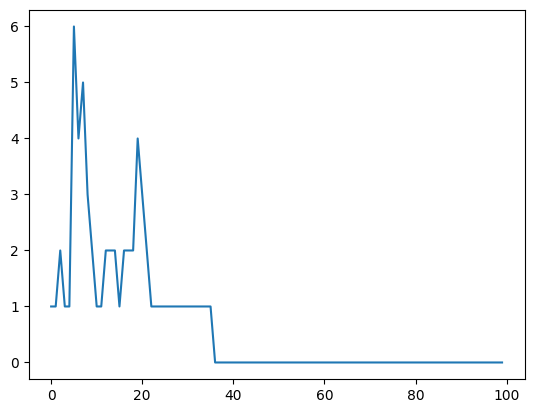

In [30]:
# 소멸의 확률을 조금 늘리면 이용자가 줄어드는 모습을 확인할 수 있습니다.

percent_disappearance = 0.2
list_activated = np.zeros(num)
list_activated[0] = 1

list_timeSeries = []
for t in range(t_period) :
  list_activated = simulation_membership_percolation(num, list_activated, df_links, percent_percolation, percent_disappearance)
  list_timeSeries.append(list_activated.copy())

list_timeSeries_num = []
for i in range(len(list_timeSeries)) :
  list_timeSeries_num.append(list_timeSeries[i].sum())

plt.plot(list_timeSeries_num)
plt.show()

# 반복해서 실행해보면 처음부터 전파 효과보다 소실 효과가 커서 0으로 수렴하기도 하고
# 전파가 더 진행되었다가 0으로 수렴하기도 함
# 현 그래프는 소실될 확률을 20%로 했을때 40개월이면 이용자가 없어짐

## 파라미터 '상관관계'

: 이렇게 입소문 전파(확산)와 이용 중단(소멸)이 **어떤 확률로 일어나는지**는 상품이나 서비스의 성질에 따라 달라지고 캠페인 유무에 따라 영향을 크게 받습니다. 그리고 이 확률이 **상품의 보급에 어떻게 영향을 주는지**(*정착했는지 아니면 잊혀지는지*)가 한층 중요합니다. 이런 보급의 모습을 파악하기 위해서는 '**상관관계**'를 그리면 알기 쉽습니다.

In [44]:
phaseDiagram[19]

array([20., 13., 17.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.])

[20. 18.  0.  4.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.]
[20. 19. 12.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.]


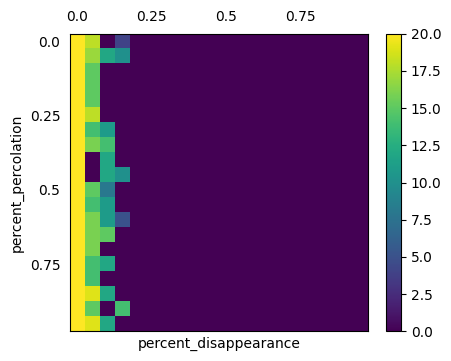

In [48]:
t_period = 100
num_phaseDiagram = 20
phaseDiagram = np.zeros((num_phaseDiagram, num_phaseDiagram))

# phaseDiagram.shape (20, 20)

for i_p in range(num_phaseDiagram) :
  for i_d in range(num_phaseDiagram) :
    percent_percolation = 0.05 * i_p # 0%~95%
    # print(percent_percolation)
    percent_disappearance = 0.05 * i_d # 0%~95%
    list_activated = np.zeros(num)
    list_activated[0] = 1
    for t in range(t_period) :
      list_activated = simulation_membership_percolation(num, list_activated, df_links, percentage_percolation, percentage_disappearance)
      phaseDiagram[i_p][i_d] = sum(list_activated) # 100개월 동안의 전파 결과(이후 for문 안에서 초기화)
      # [0][0] = 20.0 > (0% 0%)일 때의 확산 정도
      # [0][1] = 15.0 > (0% 5%)일 때의 확산 정도(소멸 확률이 더 큼)
      # [1][0] = 20.0 > (5% 0%)일 때의 확상 정도(확산 확률이 더 큼)

print(phaseDiagram[0])
# 20, 18, 0, 4, (확산 0% & 소멸 확률이 늘어갈 수록 작아짐)
print(phaseDiagram[19])
# 20, 19, 12, (확산 95% & 소멸 확률이 늘어갈 수록 작아지긴 함)

plt.matshow(phaseDiagram)
plt.colorbar(shrink=0.8)
plt.xlabel('percent_disappearance')
plt.ylabel('percent_percolation')
plt.xticks(np.arange(0.0, 20.0, 5), np.arange(0.0, 1.0, 0.25))
plt.yticks(np.arange(0.0, 20.0, 5), np.arange(0.0, 1.0, 0.25))
plt.tick_params(bottom= False,
                left= False,
                right= False,
                top= False)
plt.show()

# 소멸 확률이 0%일 때 20명 전원 확산
# 소멸 확률이 늘어감에 따라 확산 정도가 낮아짐
# 소멸 확률이 20%~30%를 넘어가면 입소문 확률이 아무리 높더라도 이용자는 증가하지 않는 모습


In [ ]:
# 이 결과는 입소문이 일어날 확률과 소멸이 일어날 확률을 조금씩 변화시키면서
# 100개월 후에 몇 명이 계속 이용하는지를 색으로 표시한 것입니다.
# 소멸의 확률이 낮으면 입소문의 확률이 어느 정도 낮아도 탈퇴 없이 20명 전원이 이용하고 있는 것을 볼 수 있습니다.
# 반대로 소멸의 확률이 20~30%를 넘으면 아무리 입소문 확률이 높더라도 이용자는 증가하지 않는 모습을 볼 수 있습니다.
# 이렇게 파라미터의 관계와 성질을 이해하는 데 있어 상관관계 그림이 도움이 됩니다.


